# Note:: Analyze Open Fund By Windowed Revenue

In [4]:
import os
import numpy as np
import akshare as ak
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm

from simple_dice.data.processor import calc_revenue_window
from simple_dice.vis.fund_visualization import plot_fund_with_window_extrema

In [5]:
DIR_DATA = '/Users/yuliu/Documents/workspace/data/dice_data/open_fund/'
frame_index_file = os.path.join(DIR_DATA, 'all_fund_index.csv')
frame_dir = os.path.join(DIR_DATA, 'frame_cum/')
stats_dir = os.path.join(DIR_DATA, 'stats/')
os.makedirs(stats_dir, exist_ok=True)
# read frame index
frame_index_df = pd.read_csv(frame_index_file, dtype={'fund_code': str})
# Load basic stats file
fund_basic_stats_df = pd.read_csv(os.path.join(stats_dir, "annual_yields.csv"))

In [ ]:
# Filter stable funds based on criteria:
# - Year window min yield > 3%
# - Year window mean yield > 4%
# - Year window max yield < 50%
# - Week window max yield < 10%
# - Month window min yield > 1%

# Get year, month, and week window data
year_stats = fund_basic_stats_df[fund_basic_stats_df['window'] == 'year'].copy()
month_stats = fund_basic_stats_df[fund_basic_stats_df['window'] == 'month'].copy()
week_stats = fund_basic_stats_df[fund_basic_stats_df['window'] == 'week'].copy()

# Merge year and month stats
stable_candidates = year_stats[['fund_code', 'mean', 'min', 'max', 'count']].copy()
stable_candidates.columns = ['fund_code', 'mean_year', 'min_year', 'max_year', 'count_year']

# Add month min
month_min = month_stats[['fund_code', 'min']].copy()
month_min.columns = ['fund_code', 'min_month']
stable_candidates = stable_candidates.merge(month_min, on='fund_code', how='left')

# Add week max
week_max = week_stats[['fund_code', 'max']].copy()
week_max.columns = ['fund_code', 'max_week']
stable_candidates = stable_candidates.merge(week_max, on='fund_code', how='left')

# Apply filters (adjusted for realistic thresholds)
# 1. Year window min > 0%
stable_funds = stable_candidates[stable_candidates['min_year'] > 0.0].copy()

# 2. Year window mean > 1.5%
stable_funds = stable_funds[stable_funds['mean_year'] > 0.015].copy()

# 3. Year window max < 50%
stable_funds = stable_funds[stable_funds['max_year'] < 0.50].copy()

# 4. Week window max < 10%
stable_funds = stable_funds[stable_funds['max_week'] < 0.10].copy()

# 5. Month window min > 0%
stable_funds = stable_funds[stable_funds['min_month'] > -0.1].copy()

# Sort by year window mean yield (descending)
stable_funds = stable_funds.sort_values('max_year', ascending=False)

print(f"Found {len(stable_funds)} stable funds")
print("\nTop 20 stable funds:")

# Format fund_code with zero-padding
display_funds = stable_funds.head(20).copy()
display_funds['fund_code'] = display_funds['fund_code'].astype(str).str.zfill(6)
display_funds

Found 3137 stable funds

Top 20 stable funds:


,fund_code,mean_year,min_year,max_year,count_year,min_month
17641,022312,0.375967,0.184900,0.498036,23,-0.074879
18835,023855,0.458287,0.429085,0.497416,6,-0.057781
17295,021953,0.302575,0.132867,0.494559,175,-0.094500
4810,007556,0.079871,0.005406,0.493819,1139,-0.005936
16901,021526,0.343800,0.116058,0.492736,227,-0.090636
16890,021513,0.332343,0.154915,0.486747,160,-0.088595
16907,021514,0.328443,0.158816,0.481616,160,-0.088940
18363,023135,0.345753,0.203220,0.481589,45,-0.097865
19204,159231,0.381077,0.279800,0.478883,17,-0.083035
18361,023136,0.342116,0.199940,0.477507,45,-0.098028


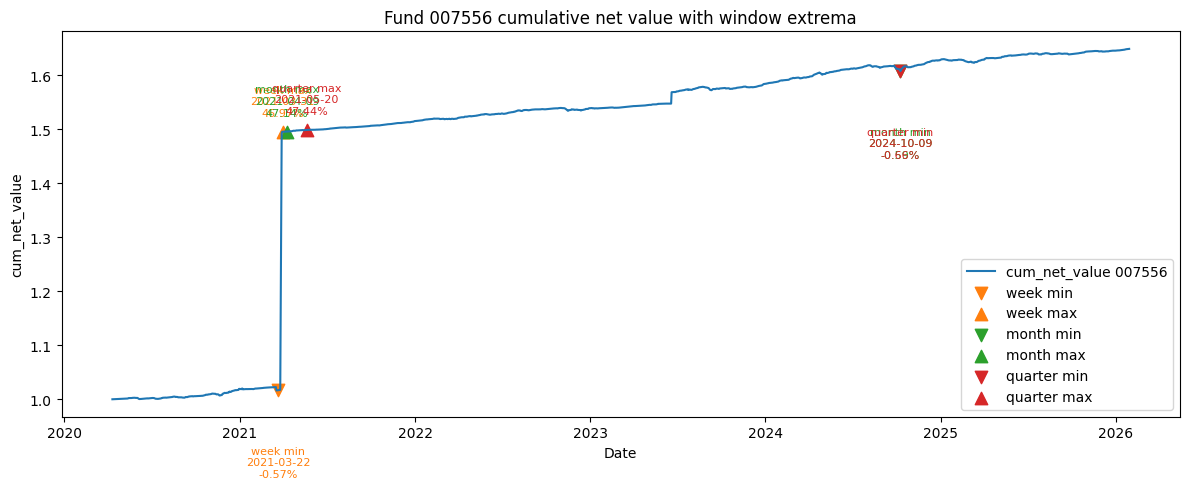

In [20]:
# Draw the acc_value with min/max markers
plot_fund_with_window_extrema('007556', frame_dir=frame_dir)

General rules:
- The general assumption is: worst case, no gain no lose
- So buy only in the relative low time and sell at relative high time
- Where the reference come from? The average revenue gain in the window period

Split into 2 categories:
  - Stable funds -- target annue ratio = 3.7%
    - count of revenue data points > 360
    - min revenue over 360 days window > 3.6%
    - min revenue over 180 days window > 1.8%
    - min revenue over 90 days window > 0.9%
  - Aggressive funds -- target annue ratio = 10.0%
    - count of revenue data points > 360
    - min revenue over 360 days window > 3.6%
    - avg revenue over 360 days window >= 10.0%, avg - std >= 3.6%

In [66]:
def filter_stable_funds(stats_merged):
    """
    Filter for stable funds based on criteria:
    - count of revenue data points > 360
    - min revenue over 360 days window > 3.6%
    - min revenue over 180 days window > 1.8%
    - min revenue over 90 days window > 0.9%
    
    Args:
        stats_merged: DataFrame with merged statistics and fund categories
    
    Returns:
        DataFrame with filtered stable funds
    """
    # Get data for each window size
    stats_360 = stats_merged[stats_merged['window_size'] == 360].copy()
    stats_180 = stats_merged[stats_merged['window_size'] == 180].copy()
    stats_90 = stats_merged[stats_merged['window_size'] == 90].copy()
    
    # Merge window data for easier filtering
    stable_candidates = stats_360[['fund_code', 'count', 'min', 'std', 'mean']].copy()
    stable_candidates.columns = ['fund_code', 'count_360', 'min_360', 'std_360', 'mean_360']
    
    # Add 180-day min
    stats_180_min = stats_180[['fund_code', 'min']].copy()
    stats_180_min.columns = ['fund_code', 'min_180']
    stable_candidates = stable_candidates.merge(stats_180_min, on='fund_code', how='left')
    
    # Add 90-day min
    stats_90_min = stats_90[['fund_code', 'min']].copy()
    stats_90_min.columns = ['fund_code', 'min_90']
    stable_candidates = stable_candidates.merge(stats_90_min, on='fund_code', how='left')
    
    # Apply filters
    # 1. Count of revenue data points > 360
    stable_filtered = stable_candidates[stable_candidates['count_360'] > 360].copy()
    
    # 2. Min revenue over 360 days > 3.6%
    stable_filtered = stable_filtered[stable_filtered['min_360'] > 0.036].copy()
    
    # 3. Min revenue over 180 days > 1.8%
    stable_filtered = stable_filtered[stable_filtered['min_180'] > 0.018].copy()
    
    # 4. Min revenue over 90 days > 0.9%
    stable_filtered = stable_filtered[stable_filtered['min_90'] > 0.009].copy()
    
    print(f"Filtered {len(stable_filtered)} stable funds from {len(stable_candidates)} candidates")
    
    # Get full fund info for stable funds
    stable_funds = stats_merged[stats_merged['fund_code'].isin(stable_filtered['fund_code'])].copy()
    
    return stable_funds, stable_filtered


# Apply the filter
stable_funds_full, stable_funds_summary = filter_stable_funds(stats_df)
# print(f"\nStable funds found: {stable_funds_summary[['fund_code', 'mean_360', 'min_360', 'min_180', 'min_90']].to_string(index=False)}")
stable_funds_summary

Filtered 3 stable funds from 2604 candidates


,fund_code,count_360,min_360,std_360,mean_360,min_180,min_90
1493,511880,2761,1.7740,3.034598,3.887083,0.7939,0.3796
2036,519972,372,0.2267,0.049098,0.307407,0.0972,0.0095
2037,519973,372,0.2524,0.049163,0.334020,0.1097,0.0162
